# 이커머스 고객 이탈 예측 — EDA

`01_eda_log.ipynb`에서 검증한 정제 규칙과 시점 설계를 바탕으로


고객 스냅샷을 생성하고, RFM 피처와 이탈률의 관계를 확인한다.

In [1]:
import sys
sys.path.append("..")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

from src.features import make_snapshot

snapshot = make_snapshot(pd.Timestamp("2011-09-10"), window=90)
print(snapshot.shape)
print("이탈률:", snapshot["churn"].mean().round(3))
snapshot.head()

(4320, 8)
이탈률: 0.494


,CustomerID,last_purchase,first_purchase,frequency,net_revenue,recency_days,tenure_days,churn
0,12346,2011-01-18 10:17:00,2010-03-02 13:08:00,4,169.36,234,556,1
1,12347,2011-08-02 08:48:00,2010-10-31 14:20:00,6,4114.18,38,313,0
2,12348,2011-04-05 10:47:00,2010-09-27 14:59:00,4,1388.40,157,347,0
3,12349,2010-10-28 08:23:00,2009-12-04 12:49:00,3,2196.99,316,644,0
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,294.40,219,219,1


## 06. 변수 간 관계 시각화 (RFM × 이탈률)

recency_days, frequency, net_revenue, tenure_days 각각이 이탈과 관계 있는지
5분위별 이탈률로 확인한다.

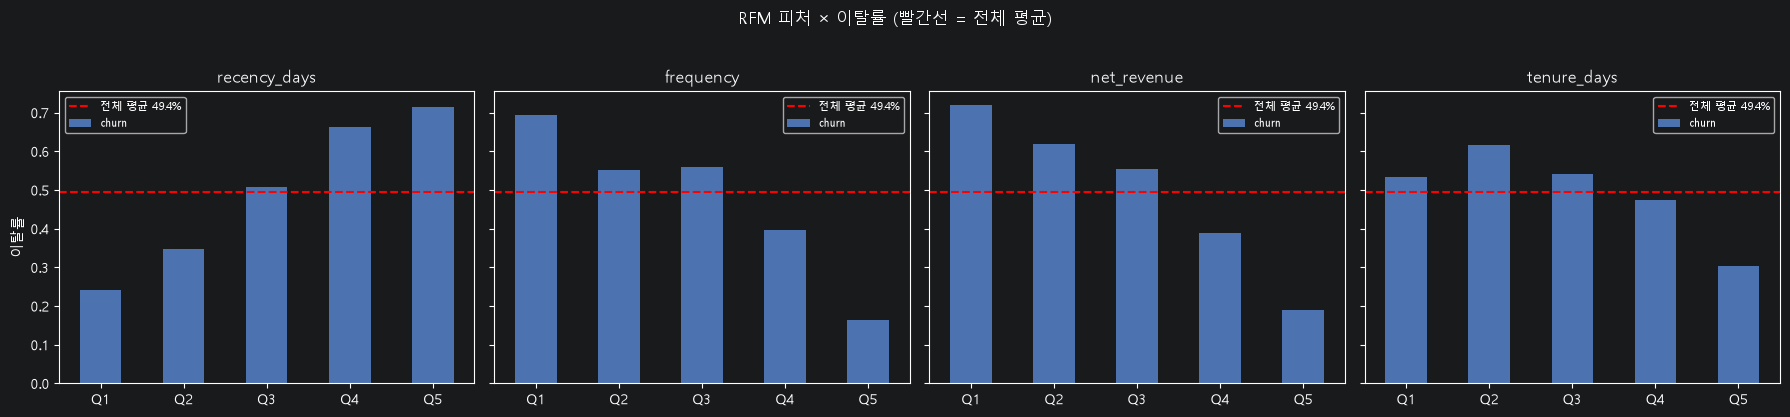

In [2]:
target = "churn"
base_rate = snapshot[target].mean()

num_cols = ["recency_days", "frequency", "net_revenue", "tenure_days"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for ax, col in zip(axes, num_cols):
    rate = snapshot.groupby(pd.qcut(snapshot[col], 5, duplicates="drop"), observed=True)[target].mean()
    rate.plot.bar(ax=ax, color="#4C72B0")
    ax.axhline(base_rate, color="red", ls="--", label=f"전체 평균 {base_rate:.1%}")
    ax.set_title(col); ax.set_xlabel("")
    ax.set_xticklabels([f"Q{i+1}" for i in range(len(rate))], rotation=0)
    ax.legend(fontsize=8)
axes[0].set_ylabel("이탈률")
fig.suptitle("RFM 피처 × 이탈률 (빨간선 = 전체 평균)", y=1.03)
plt.tight_layout(); plt.show()

### 06 해석 — RFM × 이탈률

- **recency_days**: 24%→71% — 최강 신호, 단조 증가
- **frequency**: 69%→16% — 강한 신호, 단조 감소
- **net_revenue**: 71%→19% — 강한 신호, 단조 감소
- **tenure_days**: 53%→31%로 하락 추세이나 Q2(62%)가 Q1보다 높음 — 완전 단조 아님.
  초반 정착 실패 구간 존재 가능성, 추가 세분화 검토 대상
- **핵심 차이**: 합성 데이터(11개 중 3개만 신호)와 달리, 로그에서 직접 설계한 4개
  전부가 강한 신호 — 실거래 데이터의 행동 변수가 이탈과 밀접히 연관됨을 확인
- avg_order_value, distinct_products, 반품비율, country 등
  추가 피처로 신호를 보강하고, 상관관계(07)로 피처 간 중복 여부 확인

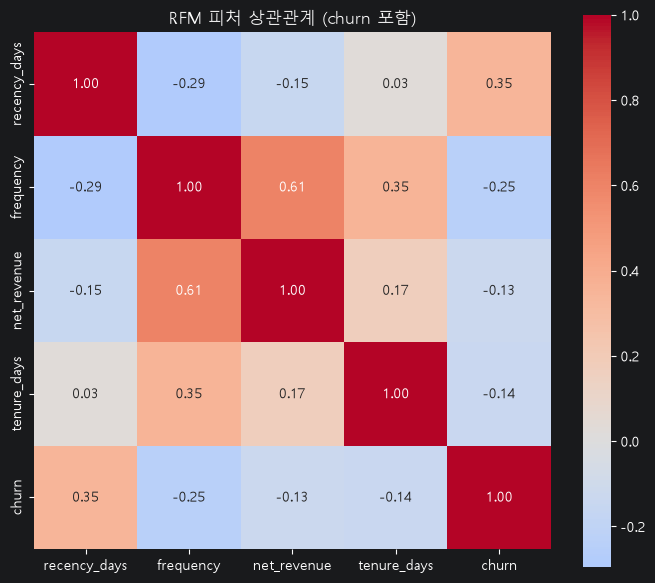

In [3]:
corr_cols = ["recency_days", "frequency", "net_revenue", "tenure_days", "churn"]
corr_mat = snapshot[corr_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("RFM 피처 상관관계 (churn 포함)")
plt.tight_layout(); plt.show()

### 07 해석 — 상관관계 (1차, RFM 4개)

**피처 간**: frequency↔net_revenue만 중간 수준 상관(0.61), 나머지는 0.35 이하로 약함
→ 심각한 다중공선성은 없음. recency_days가 특히 독립적

**피처↔타깃**: recency_days(0.35) > frequency(−0.25) > tenure_days(−0.14) ≈ net_revenue(−0.13)
→ frequency가 net_revenue보다 겹치는 정보(0.61)임에도 이탈 예측력은 더 강함(−0.25 vs −0.13)
  → "구매 빈도"가 "구매 금액"보다 이탈 신호로서 더 유용

**다음**: 09에서 avg_order_value(=net_revenue/frequency), 상품 다양성, 반품비율, country 추가 후
07 재실행하여 최종 피처셋의 다중공선성 확정

## 08. 전처리 방향 정리

01~07의 발견을 전처리 방침으로 변환한다. 실제 처리는 Train/Test 분리 후
Pipeline 안에서 수행한다 (분리 전 처리는 데이터 누수).

| 항목 | 근거 | 처리 방침 |
|---|---|---|
| CustomerID | 식별자, 예측력 없음 | 학습에서 제거 |
| last_purchase, first_purchase | recency_days/tenure_days로 이미 파생 | 원본 날짜 컬럼 제거 (정보 중복) |
| net_revenue | 파레토 구조, mean≫median (03·05 유사 사례) | 로그 변환 (log1p) |
| frequency | 이탈과 상관 -0.25, net_revenue와 상관 0.61 | 유지, 다중공선성 재확인(07 2차) 대상 |
| recency_days, tenure_days | 신호 확인, 스케일 상이 | 선형 모델용 StandardScaler |
| country (예정) | 09에서 추가 예정 | 원핫 인코딩 |
| 결측 | 스냅샷 생성 로직상 발생 가능성 낮음 | 09 진행 전 확인 필요 |
| 이상값(초대형 고객) | 진짜 큰손으로 검증됨(1부 06) | 제거하지 않고 로그 변환으로 스케일만 조정 |

In [7]:
snapshot.isna().sum()

#결측: 전 컬럼 0건 관찰— 스냅샷 생성 로직상 활성 고객은 반드시 구간 거래가 있으므로
# Recency/Frequency/Monetary 계산에 결측 발생 여지 없음. 처리 불필요.

CustomerID        0
last_purchase     0
first_purchase    0
frequency         0
net_revenue       0
recency_days      0
tenure_days       0
churn             0
dtype: int64

## 09. Feature Engineering — 피처 보강

06~07에서 RFM 4개가 유효함을 확인했으나 피처 수가 적어 보강한다.

새 피처는 관찰구간(`obs`) 데이터에서 추가 계산한다.

In [9]:
from src.features import _prepare_base
import pandas as pd

CUTOFF = pd.Timestamp("2011-09-10")
prod_all = _prepare_base()  # 취소 포함, 상품+회원만
obs_all = prod_all[prod_all["InvoiceDate"] <= CUTOFF]

extra = obs_all[obs_all["CustomerID"].isin(snapshot["CustomerID"])].groupby("CustomerID").agg(
    distinct_products=("StockCode", "nunique"),
    total_qty=("Quantity", lambda s: s.abs().sum()),
    return_qty=("Quantity", lambda s: s[s < 0].abs().sum()),
    country=("Country", lambda s: s.mode().iloc[0]),
).reset_index()

extra["return_ratio"] = extra["return_qty"] / extra["total_qty"]

snapshot = snapshot.merge(extra[["CustomerID", "distinct_products", "return_ratio", "country"]],
                           on="CustomerID", how="left")
snapshot["avg_order_value"] = snapshot["net_revenue"] / snapshot["frequency"]

print(snapshot.shape)
snapshot.head()

(4320, 12)


,CustomerID,last_purchase,first_purchase,frequency,net_revenue,recency_days,tenure_days,churn,distinct_products,return_ratio,country,avg_order_value
0,12346,2011-01-18 10:17:00,2010-03-02 13:08:00,4,169.36,234,556,1,25,0.499919,United Kingdom,42.340000
1,12347,2011-08-02 08:48:00,2010-10-31 14:20:00,6,4114.18,38,313,0,107,0.000000,Iceland,685.696667
2,12348,2011-04-05 10:47:00,2010-09-27 14:59:00,4,1388.40,157,347,0,24,0.000000,Finland,347.100000
3,12349,2010-10-28 08:23:00,2009-12-04 12:49:00,3,2196.99,316,644,0,91,0.005020,Italy,732.330000
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,294.40,219,219,1,16,0.000000,Norway,294.400000


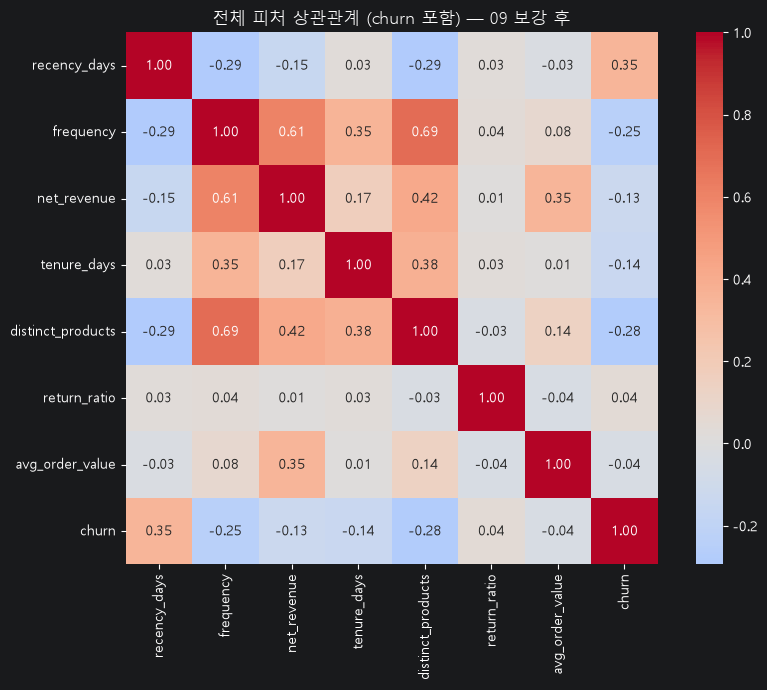

In [10]:
corr_cols = ["recency_days", "frequency", "net_revenue", "tenure_days",
             "distinct_products", "return_ratio", "avg_order_value", "churn"]
corr_mat = snapshot[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("전체 피처 상관관계 (churn 포함) — 09 보강 후")
plt.tight_layout(); plt.show()

### 07 해석 — 상관관계 (2차, 09 보강 후)

**새 피처 성적**
- distinct_products: churn과 −0.28 (2번째로 강한 신호). 단 frequency와 0.69로 상당히 겹침
- return_ratio: churn과 0.04 (무신호) — "반품 많으면 불만족→이탈" 가설 기각
- avg_order_value: churn과 −0.04 (무신호) — net_revenue(0.35)와는 상관 있으나 이탈 예측력 없음

**신호 순위**: recency_days(0.35) > distinct_products(−0.28) ≈ frequency(−0.25)
> tenure_days(−0.14) ≈ net_revenue(−0.13) > avg_order_value·return_ratio(≈0, 무신호)

**시사점**: 파생변수가 항상 신호를 만들지 않음(가설 검증 필요성 재확인).
distinct_products·frequency 간 0.69 상관은 다중공선성 후보 — 선형 모델 사용 시
둘 중 하나 축소 검토 (또는 트리 모델로 자동 처리에 맡김)

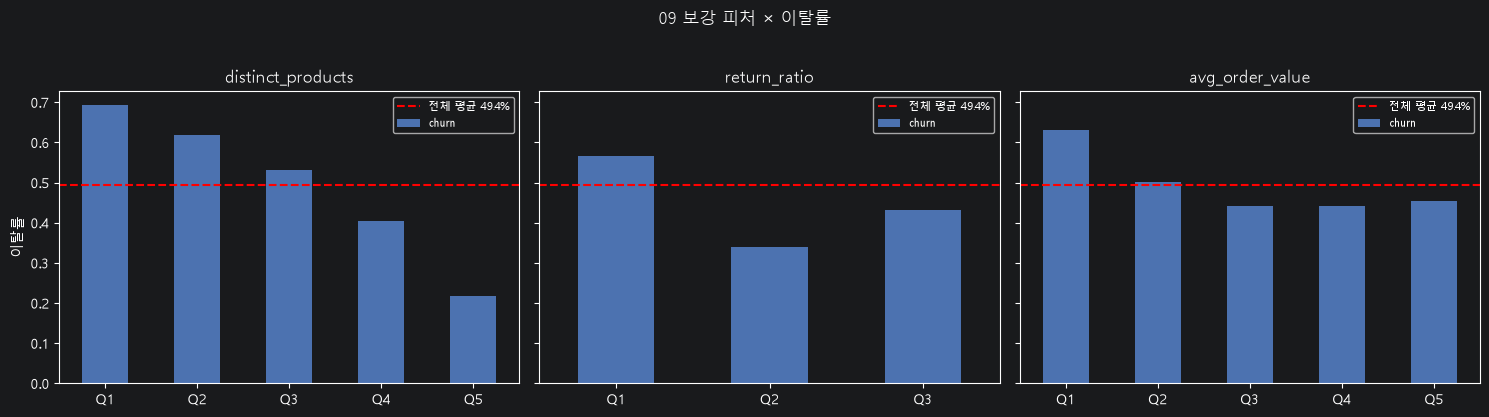

In [11]:
new_cols = ["distinct_products", "return_ratio", "avg_order_value"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, col in zip(axes, new_cols):
    rate = snapshot.groupby(pd.qcut(snapshot[col], 5, duplicates="drop"), observed=True)["churn"].mean()
    rate.plot.bar(ax=ax, color="#4C72B0")
    ax.axhline(base_rate, color="red", ls="--", label=f"전체 평균 {base_rate:.1%}")
    ax.set_title(col); ax.set_xlabel("")
    ax.set_xticklabels([f"Q{i+1}" for i in range(len(rate))], rotation=0)
    ax.legend(fontsize=8)
axes[0].set_ylabel("이탈률")
fig.suptitle("09 보강 피처 × 이탈률", y=1.03)
plt.tight_layout(); plt.show()

In [12]:
country_churn = snapshot.groupby("country")["churn"].agg(["mean", "count"]).sort_values("count", ascending=False)
country_churn.head(10)

,mean,count
country,,
United Kingdom,0.496313,3933
Germany,0.341772,79
France,0.380282,71
Spain,0.423077,26
Belgium,0.423077,26
Switzerland,0.500000,20
Portugal,0.500000,14
Italy,0.461538,13
Australia,0.500000,12


### 06 재실행 해석 — 09 보강 피처

- **distinct_products**: 69%→22%, 뚜렷한 단조 감소. 상관계수(-0.28)와 일치, 신호 확정
- **return_ratio**: 값 대부분이 0이라 5분위 불가(3개만 생성), 패턴도 비단조(56→34→43%)
  → 무신호 확정
- **avg_order_value**: Q1(62%)에서 급락 후 Q2~Q5는 평평(44~50%) — **임계값 패턴**.
  선형 상관계수(-0.04)로는 안 보이던 구조. "주문금액이 극도로 낮은 고객만 위험군"으로 해석,
  이진 플래그(예: is_low_value) 피처가 연속값보다 유용할 수 있음
- **country**: UK(n=3,933)는 전체 평균과 유사. 그 외 국가는 표본 12~79명으로 소규모라
  이탈률 차이(34~67%)를 신호로 신뢰하기 어려움 → 국가 피처는 "UK vs 비UK" 이진화 검토

### 이진화 피처 추가

- **is_low_value**: avg_order_value 하위 20%(Q1) 이진 플래그.
  06에서 Q1만 이탈률이 튀고 Q2~Q5는 평평한 계단식 패턴을 보여, 연속값 대신
  "위험군이냐 아니냐"로 단순화하는 것이 선형 모델의 신호 포착에 유리함
- **is_uk**: 국가를 "UK vs 비UK" 이진 플래그로 압축.
  UK(3,933명)를 제외한 국가는 표본이 12~79명으로 작아 국가별 세분화(원핫 인코딩)가
  오히려 노이즈에 가까운 희소 정보가 됨. 이진화로 양쪽 표본을 충분히 확보

In [13]:
q20 = snapshot["avg_order_value"].quantile(0.2)
snapshot["is_low_value"] = (snapshot["avg_order_value"] <= q20).astype(int)
snapshot["is_uk"] = (snapshot["country"] == "United Kingdom").astype(int)

print(f"is_low_value=1 (avg_order_value ≤ {q20:.2f}): {snapshot['is_low_value'].sum()}명")
print(f"is_uk=1: {snapshot['is_uk'].sum()}명 / is_uk=0: {(snapshot['is_uk']==0).sum()}명")

is_low_value=1 (avg_order_value ≤ 147.13): 864명
is_uk=1: 3933명 / is_uk=0: 387명


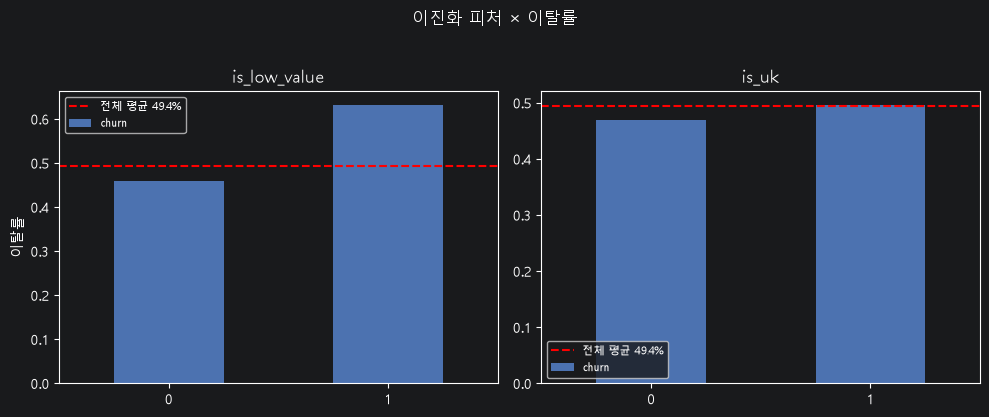

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col in zip(axes, ["is_low_value", "is_uk"]):
    rate = snapshot.groupby(col)["churn"].mean()
    rate.plot.bar(ax=ax, color="#4C72B0")
    ax.axhline(base_rate, color="red", ls="--", label=f"전체 평균 {base_rate:.1%}")
    ax.set_title(col); ax.set_xlabel(""); ax.set_xticklabels(["0", "1"], rotation=0)
    ax.legend(fontsize=8)
axes[0].set_ylabel("이탈률")
fig.suptitle("이진화 피처 × 이탈률", y=1.03)
plt.tight_layout(); plt.show()

### 이진화 피처 검증 결과

- **is_low_value**: 864명(하위 20%). 이탈률 0군 ≈44% vs 1군 ≈62% — 뚜렷한 차이, 신호 확정
- **is_uk**: UK 3,933명 vs 비UK 387명. 이탈률 47% vs 50% — 차이 미미, 약한 신호
  (표본 불균형 문제는 해결했으나 원래 국가 자체가 강한 신호는 아니었음)

## 10. 최종 인사이트 및 다음 단계

### 고객 스냅샷 요약
- 기준일 2011-09-10, 관찰구간 365일 활성 조건, 예측구간 90일 → 이탈 라벨
- 활성 고객 4,320명, 이탈률 49.4%

### 최종 피처 세트
| 등급 | 피처 | 근거 |
|---|---|---|
| 강한 신호 | recency_days | 이탈률 24%→71%, 상관 0.35 (최강) |
| 강한 신호 | frequency | 이탈률 69%→16%, 상관 -0.25 |
| 강한 신호 | distinct_products | 이탈률 69%→22%, 상관 -0.28 (단 frequency와 상관 0.69, 중복 주의) |
| 강한 신호 | is_low_value | 이탈률 44%→62% (avg_order_value 하위 20% 이진화) |
| 중간 신호 | tenure_days | 상관 -0.14, 비단조(Q2 이상) |
| 중간 신호 | net_revenue | 상관 -0.13, 로그 변환 필요(파레토 구조) |
| 약한 신호 | is_uk | 47%→50%, 표본 불균형 해결했으나 원 신호 자체가 약함 |
| 탈락 | return_ratio | 상관 0.04, 비단조 — 가설(반품→이탈) 기각 |
| 탈락 | avg_order_value(연속형) | 상관 -0.04, 이진화 버전(is_low_value)으로 대체 |

### 이 데이터 EDA의 특이점 (발표 할때 주의해야할점 한번더 언급하겠습니당)
1. 타깃과 고객 단위 표가 없어 스냅샷 생성 자체가 FE와 전처리를 겸함 (일반 10단계 순서의 변형)
2. 합성 데이터와 반대로, 직접 설계한 피처 대부분이 신호를 보임 — 실거래 행동이 이탈과 밀접
3. 파생변수가 항상 신호를 만들진 않음(return_ratio 기각) — 가설-검증 사이클의 중요성
4. 계단식 패턴(avg_order_value)은 상관계수로 안 잡히고 그래프에서만 드러남 — 시각화의 필요성 재확인

###  해야할것.(확인 후 삭제 예정, 아마 월요일쯤)
- 전처리 결과서 작성 → Train/Val/Test 분리 → sklearn Pipeline 베이스라인 (로지스틱 vs 트리)
- 민감도 분석: 60일/120일 스냅샷도 생성해 라벨 정의에 대한 결론의 강건성 확인 (모델 확정 후 시간 여유 시  )
- 피처셋 비교 실험, SHAP 해석, 비용 기반 threshold, Streamlit

## 모델링용 테이블 확정

10의 최종 피처 세트를 바탕으로, 실제 모델에 넣을 컬럼만 골라 모델링용 테이블을 만든다.

In [15]:
model_cols = [
    "recency_days", "frequency", "distinct_products",
    "net_revenue", "tenure_days", "is_low_value", "is_uk",
    "churn"
]
model_table = snapshot[["CustomerID"] + model_cols].copy()
print(model_table.shape)
model_table.head()

(4320, 9)


,CustomerID,recency_days,frequency,distinct_products,net_revenue,tenure_days,is_low_value,is_uk,churn
0,12346,234,4,25,169.36,556,1,1,1
1,12347,38,6,107,4114.18,313,0,0,0
2,12348,157,4,24,1388.40,347,0,0,0
3,12349,316,3,91,2196.99,644,0,0,0
4,12350,219,1,16,294.40,219,0,0,1


## feature 연구용 ## 건들지말것

In [17]:
from src.features import _prepare_base

CUTOFF = pd.Timestamp("2011-09-10")
prod_all = _prepare_base()
obs_active = prod_all[(prod_all["InvoiceDate"] <= CUTOFF) &
                       (prod_all["CustomerID"].isin(snapshot["CustomerID"]))]

# 파생 3개
snapshot["avg_days_between_orders"] = snapshot["tenure_days"] / snapshot["frequency"]
snapshot["has_return"] = (snapshot["return_ratio"] > 0).astype(int)

recent_start = CUTOFF - pd.Timedelta(days=90)
recent_freq = obs_active[obs_active["InvoiceDate"] >= recent_start].groupby("CustomerID")["Invoice"].nunique()
snapshot["recent_activity_ratio"] = snapshot["CustomerID"].map(recent_freq).fillna(0) / snapshot["frequency"]

new3 = ["avg_days_between_orders", "has_return", "recent_activity_ratio"]
snapshot[new3].describe()

저장됨: C:\Users\munkyu\Desktop\skn33-2nd-5team\data\online_retail_II.csv


,avg_days_between_orders,has_return,recent_activity_ratio
count,4320.000000,4320.000000,4320.000000
mean,112.678434,0.450926,0.164484
std,89.070980,0.497644,0.277718
min,0.000000,0.000000,0.000000
25%,43.909722,0.000000,0.000000
50%,85.000000,0.000000,0.000000
75%,158.687500,1.000000,0.200000
max,364.000000,1.000000,1.000000


In [18]:
snapshot["avg_days_between_orders"] = snapshot["tenure_days"] / snapshot["frequency"]
snapshot["has_return"] = (snapshot["return_ratio"] > 0).astype(int)

# 최근 90일 활동 비율 (관찰구간 전체 대비)
recent_start = CUTOFF - pd.Timedelta(days=90)
recent_freq = obs_active[obs_active["InvoiceDate"] >= recent_start].groupby("CustomerID")["Invoice"].nunique()
snapshot["recent_activity_ratio"] = snapshot["CustomerID"].map(recent_freq).fillna(0) / snapshot["frequency"]

new3 = ["avg_days_between_orders", "has_return", "recent_activity_ratio"]
snapshot[new3].describe()

,avg_days_between_orders,has_return,recent_activity_ratio
count,4320.000000,4320.000000,4320.000000
mean,112.678434,0.450926,0.164484
std,89.070980,0.497644,0.277718
min,0.000000,0.000000,0.000000
25%,43.909722,0.000000,0.000000
50%,85.000000,0.000000,0.000000
75%,158.687500,1.000000,0.200000
max,364.000000,1.000000,1.000000


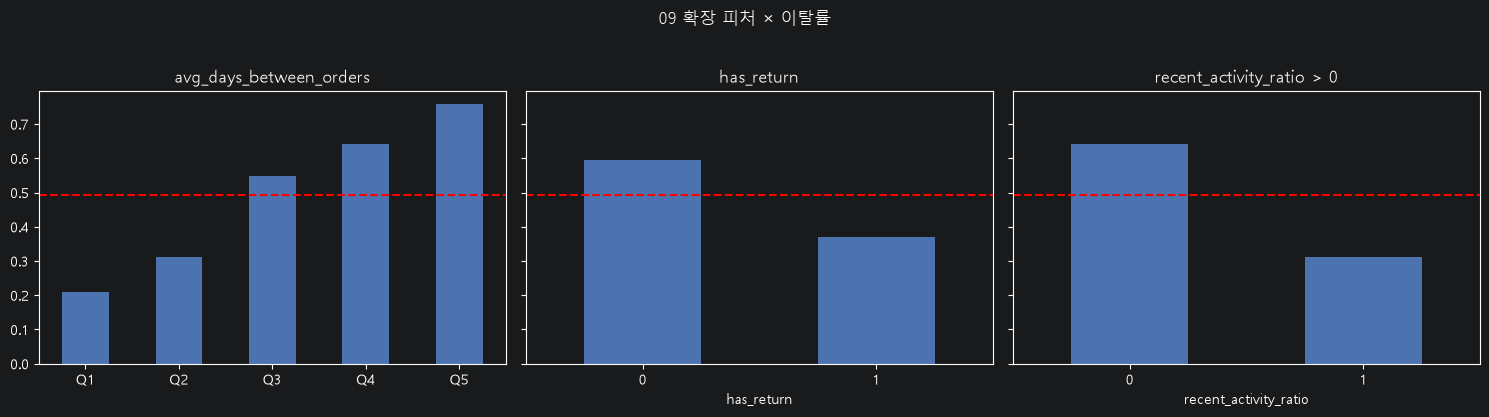

avg_days_between_orders    0.369223
has_return                -0.226365
recent_activity_ratio     -0.128230
churn                      1.000000
Name: churn, dtype: float64


In [19]:
new3 = ["avg_days_between_orders", "has_return", "recent_activity_ratio"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# avg_days_between_orders, recent_activity_ratio는 연속형 → 5분위
for ax, col in zip(axes[:1], ["avg_days_between_orders"]):
    rate = snapshot.groupby(pd.qcut(snapshot[col], 5, duplicates="drop"), observed=True)["churn"].mean()
    rate.plot.bar(ax=ax, color="#4C72B0")
    ax.axhline(base_rate, color="red", ls="--")
    ax.set_title(col); ax.set_xlabel("")
    ax.set_xticklabels([f"Q{i+1}" for i in range(len(rate))], rotation=0)

# has_return은 이진 → 그룹별
rate = snapshot.groupby("has_return")["churn"].mean()
rate.plot.bar(ax=axes[1], color="#4C72B0")
axes[1].axhline(base_rate, color="red", ls="--")
axes[1].set_title("has_return"); axes[1].set_xticklabels(["0", "1"], rotation=0)

# recent_activity_ratio도 값이 0에 몰려있어 qcut 힘들 수 있음 → 0 여부로 먼저 확인
rate = (snapshot["recent_activity_ratio"] > 0).astype(int)
rate_df = snapshot.groupby(rate)["churn"].mean()
rate_df.plot.bar(ax=axes[2], color="#4C72B0")
axes[2].axhline(base_rate, color="red", ls="--")
axes[2].set_title("recent_activity_ratio > 0")
axes[2].set_xticklabels(["0", "1"], rotation=0)

fig.suptitle("09 확장 피처 × 이탈률", y=1.03)
plt.tight_layout(); plt.show()

# 상관관계도
print(snapshot[new3 + ["churn"]].corr()["churn"])

### 09 확장 — 검증 결과

| 피처 | 이탈률 대비 | 방향 | 판정 |
|---|---|---|---|
| avg_days_between_orders | 21%→76% (55%p) | 간격 클수록 이탈↑ | **최강 신호**, 채택 |
| has_return | 60%(0)→37%(1) | 취소 경험 있으면 이탈↓ | 신호 확인, **방향 반전** — 채택 |
| recent_activity_ratio(>0) | 63%(0)→31%(1) | 최근 활동 있으면 이탈↓ | 강한 신호, 채택 |

**has_return 방향 반전 해석**: 당초 "반품 잦음 → 불만족 → 이탈"을 가정했으나 실제로는
반대. 반품은 거래가 지속되고 있다는 증거이며, 이미 이탈한 고객은 반품 기회 자체가 없다.
가설이 틀렸음을 데이터로 확인하고 방향을 수정한 사례.

**결론**: 3개 전부 채택. 최종 피처 세트 7개 → **10개**로 확장.

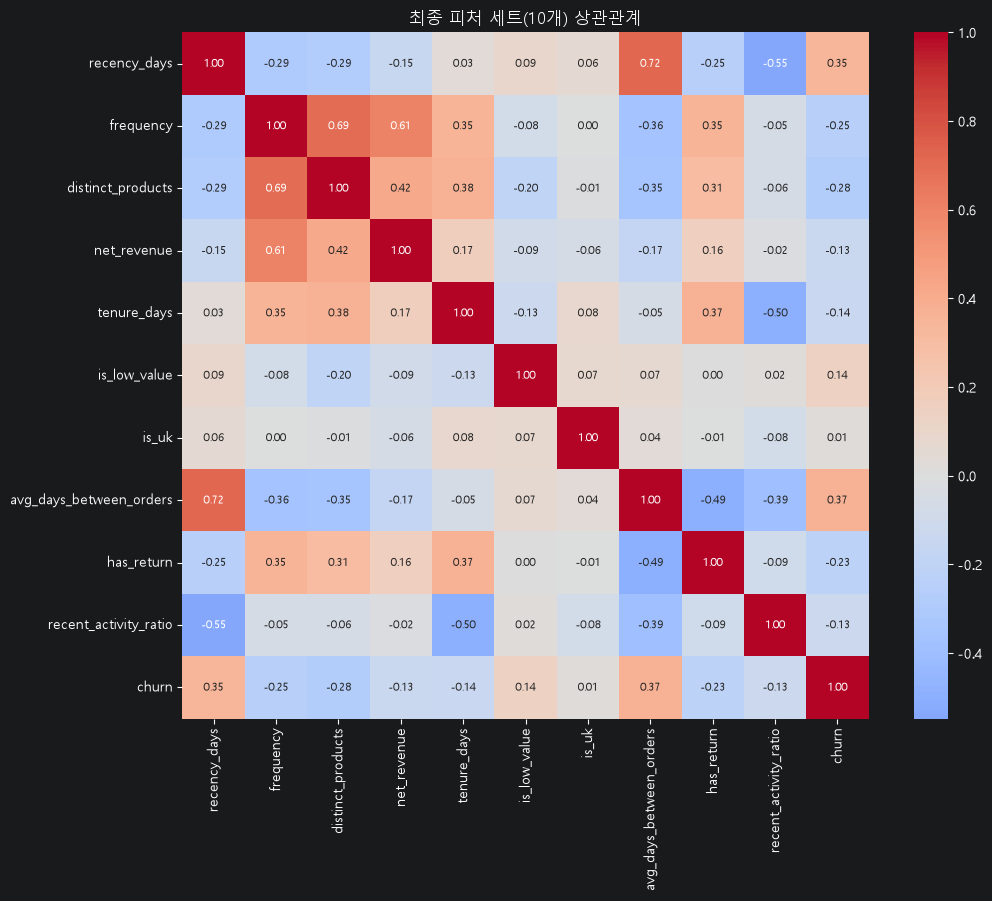

In [20]:
final_features = ["recency_days", "frequency", "distinct_products", "net_revenue",
                   "tenure_days", "is_low_value", "is_uk",
                   "avg_days_between_orders", "has_return", "recent_activity_ratio"]

corr_final = snapshot[final_features + ["churn"]].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr_final, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, annot_kws={"size":8})
plt.title("최종 피처 세트(10개) 상관관계")
plt.tight_layout(); plt.show()